## Setup

In [132]:
# GPU CHECK ────────────────────────────────────────────────────────────
%env CUDA_VISIBLE_DEVICES=0

import xgboost as xgb, os, json
import optuna, pandas as pd
import matplotlib.pyplot as plt
import shap, numpy as np
import dice_ml


from dice_ml import Dice
from scipy import sparse as sp

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import (
    accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, 
    average_precision_score, log_loss, 
    mean_squared_error, mean_absolute_error, r2_score
)

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import ElasticNet, HuberRegressor, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa: F401
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor, Pool


env: CUDA_VISIBLE_DEVICES=0


## Data Collection

In [133]:
# ── 0 · DATA ──────────────────────────────────────────────────────────
X, y = fetch_openml("adult", version=2, as_frame=True, return_X_y=True)
y = (y == ">50K")  # binary labels

cat = X.select_dtypes("category").columns
num = X.select_dtypes(include=["int", "float"]).columns
enc = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat),
     ("num", "passthrough",                         num)]
)

# 60% train, 20% validation, 20% test
X_tr, X_temp, y_tr, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=0, stratify=y
)
X_va, X_te, y_va, y_te = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp
)

X_tr_enc = enc.fit_transform(X_tr)
X_va_enc = enc.transform(X_va)
X_te_enc = enc.transform(X_te)

# Ensure CSR for robust slicing/stacking
if sp.issparse(X_tr_enc): X_tr_enc = X_tr_enc.tocsr()
if sp.issparse(X_va_enc): X_va_enc = X_va_enc.tocsr()
if sp.issparse(X_te_enc): X_te_enc = X_te_enc.tocsr()

In [64]:
# Helper to simulate missing values for features
def inject_missing(X_df, num_cols, cat_cols, rate, rng):
    """Return a copy of X_df with NaNs injected at `rate` into both num & cat columns."""
    if rate <= 0:
        return X_df.copy()
    Xm = X_df.copy()
    n = len(Xm)
    # numeric
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all():  # avoid all-NaN column
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    # categorical
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all():
            m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

In [65]:

def objective(trial):
    # ----- XGBoost hyperparameters (widened) -----
    params = {
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "n_estimators":  trial.suggest_int("n_estimators", 200, 1000, step=100),
        "max_depth":     trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.5, log=True),

        "min_child_weight": trial.suggest_float("min_child_weight", 0.1, 100.0, log=True),
        "gamma":            trial.suggest_float("gamma", 0.0, 10.0),
        "lambda":           trial.suggest_float("lambda", 1e-4, 100.0, log=True),
        "alpha":            trial.suggest_float("alpha", 1e-4, 100.0, log=True),
        "subsample":        trial.suggest_float("subsample", 0.2, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),

        "tree_method": "gpu_hist",
        "grow_policy": trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"]),
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 10),
        "predictor":  "gpu_predictor",
        "objective":  "binary:logistic",
        "eval_metric": "error",  # kept as you had; we compute F1 separately
        "verbosity": 0,
        "gpu_id": 0,
        "random_state": 0,
    }
    if params["booster"] == "dart":
        params.update(
            rate_drop      = trial.suggest_float("rate_drop", 0.0, 0.5),
            skip_drop      = trial.suggest_float("skip_drop", 0.0, 0.9),
            sample_type    = trial.suggest_categorical("sample_type", ["uniform", "weighted"]),
            normalize_type = trial.suggest_categorical("normalize_type", ["tree", "forest"]),
        )

    # ----- Soft knobs -----
    # RNG for row operations (independent of missing rate)
    rng_rows = np.random.default_rng(trial.number)

    # 1) Stratified row subsample of the TRAIN set
    sample_rows = trial.suggest_float("params_sample_rows", 0.5, 1.0)
    y_tr_np = np.asarray(y_tr, dtype=int)
    idx_pos = np.where(y_tr_np == 1)[0]
    idx_neg = np.where(y_tr_np == 0)[0]
    n_pos   = max(1, int(len(idx_pos) * sample_rows))
    n_neg   = max(1, int(len(idx_neg) * sample_rows))
    sub_pos = rng_rows.choice(idx_pos, size=n_pos, replace=False)
    sub_neg = rng_rows.choice(idx_neg, size=n_neg, replace=False)
    tr_sel  = np.concatenate([sub_pos, sub_neg])
    rng_rows.shuffle(tr_sel)
    ytr_sub = y_tr_np[tr_sel].astype(int)

    # --- SIMPLE missingness: apply ONLY on TRAIN (val/test clean) ---
    u = trial.suggest_float("params_missing_rate", 0.0, 0.10)
    _grid = np.array([0.00, 0.02, 0.05, 0.08, 0.10])
    missing_rate = float(_grid[np.argmin(np.abs(_grid - u))])
    rng_mask = np.random.default_rng((trial.number, int(round(missing_rate * 100))))
    X_tr_masked = inject_missing(X.iloc[tr_sel], num, cat, missing_rate, rng_mask)
    X_va_masked = X_va  # keep validation clean
    X_te_masked = X_te  # keep test clean

    # Preprocess: categorical impute+OHE; numeric passthrough (XGB handles NaN)
    preproc = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat),
        ("num", "passthrough", num),
    ])
    params["missing"] = np.nan  # tell XGBoost what 'missing' is

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va_masked)
    Xte_enc = preproc.transform(X_te_masked)

    if sp.issparse(Xtr_enc): Xtr_enc = Xtr_enc.tocsr()
    if sp.issparse(Xva_enc): Xva_enc = Xva_enc.tocsr()
    if sp.issparse(Xte_enc): Xte_enc = Xte_enc.tocsr()

    # 2) Simple re-sampling on subsample
    resampling_strategy = trial.suggest_categorical("params_resampling", ["none", "undersample", "oversample"])
    # Avoid double-compensation for imbalance
    if resampling_strategy != "none":
        params["scale_pos_weight"] = 1.0
    else:
        params["scale_pos_weight"] = trial.suggest_float("params_scale_pos_weight", 0.5, 5.0, log=True)

    ysub = np.asarray(ytr_sub, dtype=int)
    pos_idx = np.where(ysub == 1)[0]
    neg_idx = np.where(ysub == 0)[0]
    n_pos_s, n_neg_s = len(pos_idx), len(neg_idx)

    def _stack_rows(XA, XB):
        if sp.issparse(XA) or sp.issparse(XB):
            XA = XA.tocsr() if sp.issparse(XA) else sp.csr_matrix(XA)
            XB = XB.tocsr() if sp.issparse(XB) else sp.csr_matrix(XB)
            return sp.vstack([XA, XB], format="csr")
        else:
            return np.vstack([XA, XB])

    if resampling_strategy == "undersample" and n_pos_s > 0 and n_neg_s > 0:
        n_min = min(n_pos_s, n_neg_s)
        pos_keep = rng_rows.choice(pos_idx, size=n_min, replace=False)
        neg_keep = rng_rows.choice(neg_idx, size=n_min, replace=False)
        keep = np.concatenate([pos_keep, neg_keep])
        Xtr_enc = Xtr_enc[keep]
        ytr_sub = ytr_sub[keep].astype(int)
        ysub    = ytr_sub
        pos_idx = np.where(ysub == 1)[0]
        neg_idx = np.where(ysub == 0)[0]
    elif resampling_strategy == "oversample" and n_pos_s > 0 and n_neg_s > 0:
        n_max = max(n_pos_s, n_neg_s)
        pos_add = rng_rows.choice(pos_idx, size=n_max - n_pos_s, replace=True) if n_pos_s < n_max else np.array([], dtype=int)
        neg_add = rng_rows.choice(neg_idx, size=n_max - n_neg_s, replace=True) if n_neg_s < n_max else np.array([], dtype=int)
        add_idx = np.concatenate([pos_add, neg_add])
        if add_idx.size > 0:
            Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add_idx])
            ytr_sub = np.concatenate([ytr_sub, ytr_sub[add_idx]]).astype(int)
            ysub    = ytr_sub
            pos_idx = np.where(ysub == 1)[0]
            neg_idx = np.where(ysub == 0)[0]

    # 3) Random feature subset applied consistently
    feature_fraction = trial.suggest_float("params_feature_fraction", 0.5, 1.0)
    n_features = Xtr_enc.shape[1]
    k_features = max(1, int(n_features * feature_fraction))
    feat_idx   = np.sort(rng_rows.choice(np.arange(n_features), size=k_features, replace=False))

    def _col_slice(M, cols):
        return M[:, cols]

    Xtr_sub = _col_slice(Xtr_enc, feat_idx)
    Xva_sub = _col_slice(Xva_enc, feat_idx)
    Xte_sub = _col_slice(Xte_enc, feat_idx)

    # ── Semi-supervised labels (−1 == unlabeled) on TRAIN ONLY ──────────
    labeled_ratio = trial.suggest_float("params_labeled_ratio", 0.05, 0.95)
    if (len(pos_idx) > 0 and len(neg_idx) > 0) and (labeled_ratio < 1.0):
        keep_pos = max(1, int(round(len(pos_idx) * labeled_ratio)))
        keep_neg = max(1, int(round(len(neg_idx) * labeled_ratio)))
        keep_pos = min(keep_pos, len(pos_idx))
        keep_neg = min(keep_neg, len(neg_idx))

        labeled_keep = np.concatenate([
            rng_rows.choice(pos_idx, size=keep_pos, replace=False),
            rng_rows.choice(neg_idx, size=keep_neg, replace=False)
        ])

        y_semi = np.full(ytr_sub.shape, -1, dtype=int)  # unlabeled by default
        y_semi[labeled_keep] = ytr_sub[labeled_keep]
        n_labeled   = int((y_semi != -1).sum())
        n_unlabeled = int((y_semi == -1).sum())

        if n_unlabeled == 0:
            clf = xgb.XGBClassifier(**params)
            clf.fit(Xtr_sub, ytr_sub)
            n_labeled, n_unlabeled = int(len(ytr_sub)), 0
        else:
            from sklearn.semi_supervised import SelfTrainingClassifier
            st = SelfTrainingClassifier(
                estimator=xgb.XGBClassifier(**params),
                threshold=trial.suggest_float("params_selftrain_threshold", 0.6, 0.95),
                max_iter=trial.suggest_int("params_selftrain_max_iter", 5, 12),
                verbose=False
            )
            st.fit(Xtr_sub, y_semi)
            clf = st
    else:
        clf = xgb.XGBClassifier(**params)
        clf.fit(Xtr_sub, ytr_sub)
        n_labeled   = int(len(ytr_sub))
        n_unlabeled = 0

    # ── Evaluate (compute best threshold on VAL, apply to TEST) ─────────
    y_va_int = np.asarray(y_va, dtype=int)
    y_te_int = np.asarray(y_te, dtype=int)

    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    from sklearn.metrics import precision_recall_curve
    prec, rec, thr = precision_recall_curve(y_va_int, proba_va)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    best_idx = f1s.argmax()
    best_thr = 0.5 if best_idx >= len(thr) else float(thr[best_idx])

    yhat_va  = (proba_va >= best_thr).astype(int)
    f1_val   = f1_score(y_va_int, yhat_va, zero_division=0)

    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_te  = (proba_te >= best_thr).astype(int)

    # ── Log metrics (val + test) ───────────────────────────────────────
    trial.set_user_attr("f1_val", f1_val)
    trial.set_user_attr("f1_test", f1_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("acc_val",  accuracy_score(y_va_int, yhat_va))
    trial.set_user_attr("acc_test", accuracy_score(y_te_int, yhat_te))
    trial.set_user_attr("prec_val", precision_score(y_va_int, yhat_va, zero_division=0))
    trial.set_user_attr("prec_test", precision_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("rec_val",  recall_score(y_va_int, yhat_va, zero_division=0))
    trial.set_user_attr("rec_test", recall_score(y_te_int, yhat_te, zero_division=0))
    trial.set_user_attr("roc_auc_val", roc_auc_score(y_va_int, proba_va))
    trial.set_user_attr("roc_auc_test", roc_auc_score(y_te_int, proba_te))
    trial.set_user_attr("pr_auc_val", average_precision_score(y_va_int, proba_va))
    trial.set_user_attr("pr_auc_test", average_precision_score(y_te_int, proba_te))

    # log applied soft knobs
    trial.set_user_attr("best_threshold", best_thr)
    trial.set_user_attr("sample_rows", sample_rows)
    trial.set_user_attr("resampling_strategy", resampling_strategy)
    trial.set_user_attr("feature_fraction", feature_fraction)
    trial.set_user_attr("missing_rate", missing_rate)
    trial.set_user_attr("labeled_ratio", float(labeled_ratio))
    trial.set_user_attr("n_labeled", n_labeled)
    trial.set_user_attr("n_unlabeled", n_unlabeled)

    return f1_val

In [ ]:
TARGET_TRIALS = 1000

# Let ~10–15% be pure random, then switch to TPE guidance
sampler = optuna.samplers.TPESampler(
    n_startup_trials=1000,
    n_ei_candidates=64,
    consider_prior=True,
    multivariate=True,
    group=True,
    seed=0,
)

study = optuna.create_study(
    direction="maximize",
    study_name="adult_xgb_tpe_with_soft_params",
    storage="sqlite:///adult_xgb_with_soft_params.db",
    load_if_exists=True,
    sampler=sampler,
)

already_done = len(study.trials)
remaining   = max(TARGET_TRIALS - already_done, 0)

if remaining:
    print(f"Running {remaining} additional trials (have {already_done}, need {TARGET_TRIALS})")
    study.optimize(objective, n_trials=remaining, gc_after_trial=True)
else:
    print(f"Target of {TARGET_TRIALS} trials already reached – nothing to do")

print("Best F1:", study.best_value)
print("Best params:", study.best_params)

/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/optuna/_experimental.py:31: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-10-08 09:56:17,131] Using an existing study with name 'adult_xgb_tpe_with_soft_params_v2' instead of creating a new one.


Target of 100 trials already reached – nothing to do
Best F1: 0.5890388681086356
Best params: {'booster': 'gbtree', 'n_estimators': 900, 'max_depth': 12, 'learning_rate': 0.0014751085629446875, 'min_child_weight': 6.363596390862163, 'gamma': 6.50788270377181, 'lambda': 0.021238876969796917, 'alpha': 3.43340875561599, 'subsample': 0.23981292711117033, 'colsample_bytree': 0.8122809965531889, 'grow_policy': 'lossguide', 'max_delta_step': 9, 'params_sample_rows': 0.814331414302032, 'params_missing_rate': 0.045384303790691034, 'params_resampling': 'none', 'params_scale_pos_weight': 1.7147736418093222, 'params_feature_fraction': 0.7652542668573933, 'params_labeled_ratio': 0.12090560583236738, 'params_selftrain_threshold': 0.8446710085913007, 'params_selftrain_max_iter': 9}


In [ ]:
# --- Save trials dataframe to CSV ---
df = study.trials_dataframe()
CSV = "adult_xgb_trials_with_soft_params.csv"
df.to_csv(CSV, index=False)
print(f"Saved {len(df)} trials to {CSV}")

Saved 7075 trials to adult_xgb_trials_with_soft_params_v3.csv


## Exploring collected data

In [66]:
# ========== STEP 1 · Explore the Optuna trials dataset ==========

# --- 1.1 Load ---
v1 = pd.read_csv("data/adult_xgb_trials_with_soft_params.csv", index_col=0)
v3 = pd.read_csv("data/adult_xgb_trials_with_soft_params_v3.csv", index_col=0)
print(f"Rows: {len(v1) :,} {len(v3) :,}  |  Columns: {v1.shape[1], v3.shape[1]}")
display(v1.iloc[:3, :42].T)
display(v3.iloc[:3, :51].T)

Rows: 4,013 7,075  |  Columns: (42, 51)


number,0,1,2
value,0.36609,0.61967,NaN
datetime_start,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.831814
datetime_complete,2025-09-23 10:49:52.201781,2025-09-23 10:49:52.728582,2025-09-23 10:50:07.822280
duration,0 days 00:00:34.507151,0 days 00:00:00.425862,0 days 00:00:14.990466
params_alpha,60.530821,0.507941,0.829182
params_booster,dart,gbtree,dart
params_colsample_bytree,0.83338,0.693547,0.573049
params_gamma,4.375872,5.684339,2.088768
params_grow_policy,lossguide,depthwise,depthwise
params_lambda,22.420124,0.00013,0.000929


number,0,1,2
value,0.386121,0.0,0.0
datetime_start,2025-10-03 09:24:32.727473,2025-10-03 09:26:20.428473,2025-10-03 09:26:21.400575
datetime_complete,2025-10-03 09:26:20.247780,2025-10-03 09:26:21.240707,2025-10-03 09:26:22.540409
duration,0 days 00:01:47.520307,0 days 00:00:00.812234,0 days 00:00:01.139834
params_alpha,60.530821,1.232883,0.001512
params_booster,dart,gbtree,gbtree
params_colsample_bytree,0.83338,0.549626,0.856795
params_gamma,4.375872,6.16934,6.563296
params_grow_policy,lossguide,depthwise,lossguide
params_lambda,22.420124,45.971478,0.000675


In [67]:
# Merge and tag sources
v1_ = v1.copy(); v1_["source"] = "v1"
v3_ = v3.copy(); v3_["source"] = "v3"
df = pd.concat([v1_, v3_], ignore_index=True, sort=False)

# Columns absent in v1 originally
V3_ONLY = [
    "params_params_labeled_ratio",
    "params_params_missing_rate",
    "params_params_selftrain_max_iter",
    "params_params_selftrain_threshold",
    "user_attrs_best_threshold",   # will be dropped
    "user_attrs_labeled_ratio",
    "user_attrs_missing_rate",
    "user_attrs_n_labeled",
    "user_attrs_n_unlabeled",
]

# Default fill values for v1 rows
fills_numeric = {
    "params_params_labeled_ratio": 1.0,
    "params_params_missing_rate": 0.0,
    "params_params_selftrain_max_iter": 0,
    "params_params_selftrain_threshold": 1.0,
    "user_attrs_labeled_ratio": 1.0,
    "user_attrs_missing_rate": 0.0,
}

SENTINEL = "<NOT_COLLECTED_IN_V1>"
mask_v1 = df["source"].eq("v1")

for col, val in fills_numeric.items():
    if col not in df.columns:
        df[col] = np.nan
    miss = df[col].isna() | (df[col].astype(str) == SENTINEL)
    df.loc[mask_v1 & miss, col] = val
    df[col] = pd.to_numeric(df[col])

# Drop best_threshold completely
df = df.drop(columns=["user_attrs_n_labeled", "user_attrs_n_unlabeled", "user_attrs_best_threshold"])

In [68]:
# --- 1.3 Quick preview ---
# A) Wide preview: first 5 rows with ALL columns (no truncation)
display(df.iloc[:5])

display(df.iloc[:10, :51].T)

# Optional: show *all* column names as a numbered list
for i, c in enumerate(df.columns, 1):
    print(f"{i:>3}. {c}")

,value,datetime_start,datetime_complete,duration,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,...,user_attrs_roc_auc_val,user_attrs_sample_rows,state,source,params_params_labeled_ratio,params_params_missing_rate,params_params_selftrain_max_iter,params_params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate
0,0.366090,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.201781,0 days 00:00:34.507151,60.530821,dart,0.833380,4.375872,lossguide,22.420124,...,0.799956,0.730740,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0
1,0.619670,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.728582,0 days 00:00:00.425862,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,...,0.901404,0.530113,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0
2,NaN,2025-09-23 10:49:52.831814,2025-09-23 10:50:07.822280,0 days 00:00:14.990466,0.829182,dart,0.573049,2.088768,depthwise,0.000929,...,NaN,NaN,FAIL,v1,1.0,0.0,0.0,1.0,1.0,0.0
3,0.642549,2025-09-23 10:50:38.666877,2025-09-23 10:51:13.394300,0 days 00:00:34.727423,60.530821,dart,0.833380,4.375872,lossguide,22.420124,...,0.892885,0.730740,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0
4,0.594286,2025-09-23 10:51:13.518457,2025-09-23 10:51:13.940724,0 days 00:00:00.422267,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,...,0.874227,0.530113,COMPLETE,v1,1.0,0.0,0.0,1.0,1.0,0.0


,0,1,2,3,4,5,6,7,8,9
value,0.36609,0.61967,NaN,0.642549,0.594286,0.7028,0.426952,0.654116,0.0,0.655462
datetime_start,2025-09-23 10:49:17.694630,2025-09-23 10:49:52.302720,2025-09-23 10:49:52.831814,2025-09-23 10:50:38.666877,2025-09-23 10:51:13.518457,2025-09-23 10:51:14.056072,2025-09-23 10:51:44.256588,2025-09-23 10:51:49.264659,2025-09-23 10:52:00.162444,2025-09-23 10:52:15.976721
datetime_complete,2025-09-23 10:49:52.201781,2025-09-23 10:49:52.728582,2025-09-23 10:50:07.822280,2025-09-23 10:51:13.394300,2025-09-23 10:51:13.940724,2025-09-23 10:51:44.136658,2025-09-23 10:51:49.148416,2025-09-23 10:52:00.044213,2025-09-23 10:52:15.856974,2025-09-23 10:52:16.396982
duration,0 days 00:00:34.507151,0 days 00:00:00.425862,0 days 00:00:14.990466,0 days 00:00:34.727423,0 days 00:00:00.422267,0 days 00:00:30.080586,0 days 00:00:04.891828,0 days 00:00:10.779554,0 days 00:00:15.694530,0 days 00:00:00.420261
params_alpha,60.530821,0.507941,0.829182,60.530821,0.507941,0.829182,1.428344,0.048167,0.830242,71.306485
params_booster,dart,gbtree,dart,dart,gbtree,dart,dart,dart,dart,gbtree
params_colsample_bytree,0.83338,0.693547,0.573049,0.83338,0.693547,0.573049,0.412312,0.759583,0.545135,0.209371
params_gamma,4.375872,5.684339,2.088768,4.375872,5.684339,2.088768,4.14263,2.230816,5.908728,7.220556
params_grow_policy,lossguide,depthwise,depthwise,lossguide,depthwise,depthwise,depthwise,lossguide,depthwise,lossguide
params_lambda,22.420124,0.00013,0.000929,22.420124,0.00013,0.000929,0.000243,52.05879,0.279223,15.786794


  1. value
  2. datetime_start
  3. datetime_complete
  4. duration
  5. params_alpha
  6. params_booster
  7. params_colsample_bytree
  8. params_gamma
  9. params_grow_policy
 10. params_lambda
 11. params_learning_rate
 12. params_max_delta_step
 13. params_max_depth
 14. params_min_child_weight
 15. params_n_estimators
 16. params_normalize_type
 17. params_params_decision_threshold
 18. params_params_feature_fraction
 19. params_params_resampling
 20. params_params_sample_rows
 21. params_params_scale_pos_weight
 22. params_rate_drop
 23. params_sample_type
 24. params_skip_drop
 25. params_subsample
 26. user_attrs_acc_test
 27. user_attrs_acc_val
 28. user_attrs_decision_threshold
 29. user_attrs_f1_test
 30. user_attrs_f1_val
 31. user_attrs_feature_fraction
 32. user_attrs_pr_auc_test
 33. user_attrs_pr_auc_val
 34. user_attrs_prec_test
 35. user_attrs_prec_val
 36. user_attrs_rec_test
 37. user_attrs_rec_val
 38. user_attrs_resampling_strategy
 39. user_attrs_roc_auc_test
 40

In [69]:
# --- 1.2 Column groups ---
col_groups = {
    "params":        [c for c in df.columns if c.startswith("params_")],
    "user_attrs":    [c for c in df.columns if c.startswith("user_attrs_")],
    "optuna_core":   [c for c in ["number", "value", "state", "datetime_start", "datetime_complete", "duration"] if c in df.columns],
    "other":         []
}
used = set(sum(col_groups.values(), []))
col_groups["other"] = [c for c in df.columns if c not in used]

for k in ["optuna_core", "params", "user_attrs", "other"]:
    if col_groups[k]:
        print(f"\n[{k}] ({len(col_groups[k])}):")
        preview = ", ".join(col_groups[k][:12])
        print(preview + (" ..." if len(col_groups[k]) > 12 else ""))


[optuna_core] (5):
value, state, datetime_start, datetime_complete, duration

[params] (25):
params_alpha, params_booster, params_colsample_bytree, params_gamma, params_grow_policy, params_lambda, params_learning_rate, params_max_delta_step, params_max_depth, params_min_child_weight, params_n_estimators, params_normalize_type ...

[user_attrs] (18):
user_attrs_acc_test, user_attrs_acc_val, user_attrs_decision_threshold, user_attrs_f1_test, user_attrs_f1_val, user_attrs_feature_fraction, user_attrs_pr_auc_test, user_attrs_pr_auc_val, user_attrs_prec_test, user_attrs_prec_val, user_attrs_rec_test, user_attrs_rec_val ...

[other] (1):
source


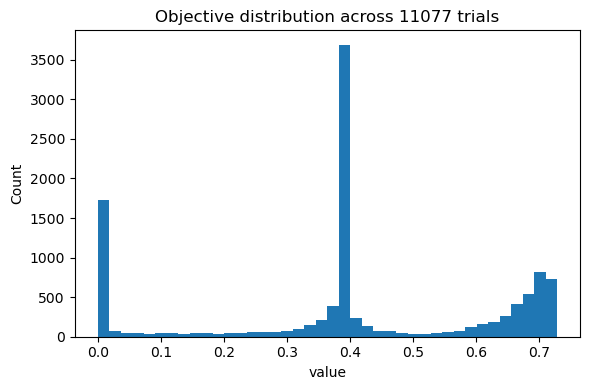

In [70]:
# --- 1.5 Objective distribution (value = F1_val) ---
if "value" in df.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df["value"].dropna(), bins=40)
    plt.xlabel("value")
    plt.ylabel("Count")
    plt.title(f"Objective distribution across {df['value'].notna().sum()} trials")
    plt.tight_layout()
    plt.show()

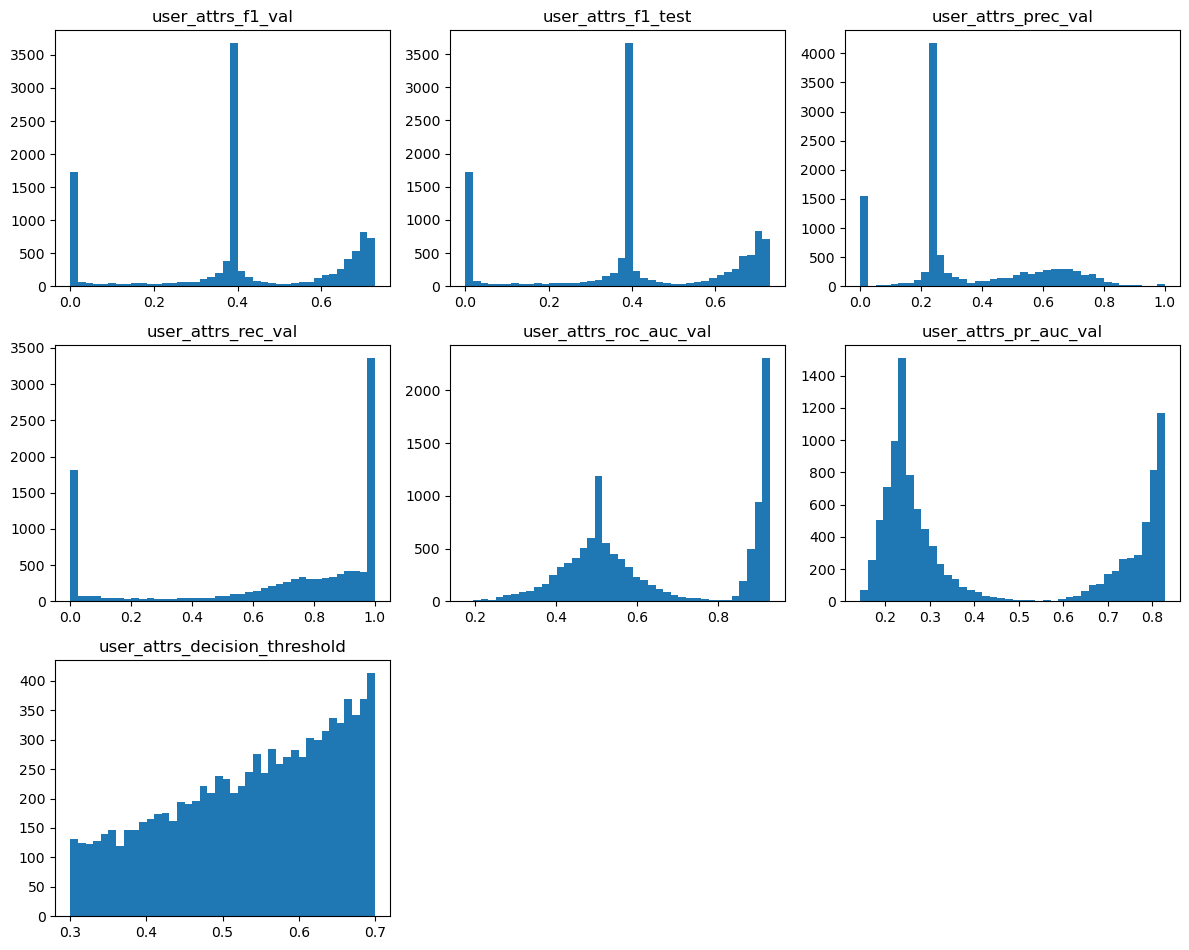

In [71]:
# --- 1.6 Key metric histograms ---
key_metrics = [m for m in [
    "user_attrs_f1_val", "user_attrs_f1_test",
    "user_attrs_prec_val", "user_attrs_rec_val",
    "user_attrs_roc_auc_val", "user_attrs_pr_auc_val",
    "user_attrs_decision_threshold"
] if m in df.columns]

if key_metrics:
    n = len(key_metrics)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(4*ncols, 3.2*nrows))
    for i, m in enumerate(key_metrics, 1):
        plt.subplot(nrows, ncols, i)
        plt.hist(pd.to_numeric(df[m], errors="coerce").dropna(), bins=40)
        plt.title(m)
        plt.tight_layout()
    plt.show()

In [72]:
# --- 1.7 Categorical knobs summary (value counts) ---
for col in ["params_booster", "params_grow_policy", "params_params_resampling"]:
    if col in df.columns:
        print(f"\nValue counts — {col}:")
        print(df[col].value_counts(dropna=False))


Value counts — params_booster:
params_booster
dart      5686
gbtree    5402
Name: count, dtype: int64

Value counts — params_grow_policy:
params_grow_policy
lossguide    5671
depthwise    5417
Name: count, dtype: int64

Value counts — params_params_resampling:
params_params_resampling
undersample    4109
none           3972
oversample     3005
NaN               2
Name: count, dtype: int64


In [73]:
# --- 1.9 Best & worst trials by objective ---
if "value" in df.columns and df["value"].notna().any():
    best_idx = df["value"].idxmax()
    worst_idx = df["value"].idxmin()
    best, worst = df.loc[best_idx], df.loc[worst_idx]
    print("\n=== BEST trial ===")
    display(best.filter(like="param_").to_frame().T)
    print(f"value (objective): {best['value']:.4f}")
    print("\n=== WORST trial ===")
    display(worst.filter(like="param_").to_frame().T)
    print(f"value (objective): {worst['value']:.4f}")


=== BEST trial ===


""
2893


value (objective): 0.7285

=== WORST trial ===


""
8


value (objective): 0.0000


## Cleaning dataset

In [74]:
# keep only successful trials
df_clean = df[df["state"] != "FAIL"].copy()

print(f"Original rows: {len(df)}")
print(f"After removing FAIL rows: {len(df_clean)}")


Original rows: 11088
After removing FAIL rows: 11077


In [75]:
drop_cols = [
    "number",
    "params_params_decision_threshold",
    "params_params_feature_fraction",
    "params_params_sample_rows",
    "params_params_resampling",
    "datetime_start",
    "datetime_complete",
    "duration",
    "state",
    "source"
]

df_clean = df_clean.drop(columns=drop_cols, errors="ignore")

## Feature engineering (soft params)

### 1) Risk preference

In [76]:
# Proxy for risk preference
thr = pd.Series(df_clean.get("user_attrs_decision_threshold", np.nan)).fillna(0.5)
spw = pd.Series(df_clean.get("params_params_scale_pos_weight", np.nan)).fillna(1.0)
res = pd.Series(df_clean.get("user_attrs_resampling_strategy", np.nan)).fillna("none").astype(str)

risk_score = (- (thr - 0.5)) + np.log(spw) + res.map({"oversample": 1, "undersample": 0.5}).fillna(0)

def label_risk(s, tol=0.2):
    if pd.isna(s): 
        return np.nan
    if abs(s) < tol:
        return "balanced"
    return "recall_pref" if s > 0 else "precision_pref"

df_clean["soft_risk_preference"] = risk_score.map(label_risk)

### 2) Decision speed (model complexity)

In [77]:
# proxy for complexity: depth × n_estimators
comp = df_clean["params_max_depth"] * df_clean["params_n_estimators"]

# thresholds: tertiles (low/med/high)
q1, q2 = comp.quantile([0.33, 0.66])

def label_speed(x):
    if pd.isna(x): 
        return np.nan
    if x < q1: 
        return "fast"
    if x < q2: 
        return "balanced"
    return "slow"

df_clean["soft_decision_speed"] = comp.map(label_speed)

### 3) Dataset size

In [78]:
# total training rows from 60/20/20 split
N_train = len(X_tr)   # reuse X_tr from split above

# fraction column (present in either user_attrs or params)
frac = df_clean.get("user_attrs_sample_rows")

# numeric: number of rows actually used in training
df_clean["soft_train_rows"] = (frac * N_train).round().astype("Int64")


In [79]:
# --- 1.3 Quick preview ---
# A) Wide preview: first 5 rows with ALL columns (no truncation)
display(df_clean.iloc[:5])

# B) Tall/rotated preview: all columns transposed (easier to scan names/values)
first_k = 48
display(df_clean.iloc[:5, :first_k].T)

# Optional: show *all* column names as a numbered list (easy to scan/search)
for i, c in enumerate(df_clean.columns, 1):
    print(f"{i:>3}. {c}")

,value,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,...,user_attrs_sample_rows,params_params_labeled_ratio,params_params_missing_rate,params_params_selftrain_max_iter,params_params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate,soft_risk_preference,soft_decision_speed,soft_train_rows
0,0.366090,60.530821,dart,0.833380,4.375872,lossguide,22.420124,0.003691,10,8,...,0.730740,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,slow,21414
1,0.619670,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,0.073092,3,5,...,0.530113,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,balanced,15535
3,0.642549,60.530821,dart,0.833380,4.375872,lossguide,22.420124,0.003691,10,8,...,0.730740,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,slow,21414
4,0.594286,0.507941,gbtree,0.693547,5.684339,depthwise,0.000130,0.073092,3,5,...,0.530113,1.0,0.0,0.0,1.0,1.0,0.0,recall_pref,balanced,15535
5,0.702800,0.829182,dart,0.573049,2.088768,depthwise,0.000929,0.452861,1,7,...,0.988230,1.0,0.0,0.0,1.0,1.0,0.0,balanced,slow,28960


,0,1,3,4,5
value,0.36609,0.61967,0.642549,0.594286,0.7028
params_alpha,60.530821,0.507941,60.530821,0.507941,0.829182
params_booster,dart,gbtree,dart,gbtree,dart
params_colsample_bytree,0.83338,0.693547,0.83338,0.693547,0.573049
params_gamma,4.375872,5.684339,4.375872,5.684339,2.088768
params_grow_policy,lossguide,depthwise,lossguide,depthwise,depthwise
params_lambda,22.420124,0.00013,22.420124,0.00013,0.000929
params_learning_rate,0.003691,0.073092,0.003691,0.073092,0.452861
params_max_delta_step,10,3,10,3,1
params_max_depth,8,5,8,5,7


  1. value
  2. params_alpha
  3. params_booster
  4. params_colsample_bytree
  5. params_gamma
  6. params_grow_policy
  7. params_lambda
  8. params_learning_rate
  9. params_max_delta_step
 10. params_max_depth
 11. params_min_child_weight
 12. params_n_estimators
 13. params_normalize_type
 14. params_params_scale_pos_weight
 15. params_rate_drop
 16. params_sample_type
 17. params_skip_drop
 18. params_subsample
 19. user_attrs_acc_test
 20. user_attrs_acc_val
 21. user_attrs_decision_threshold
 22. user_attrs_f1_test
 23. user_attrs_f1_val
 24. user_attrs_feature_fraction
 25. user_attrs_pr_auc_test
 26. user_attrs_pr_auc_val
 27. user_attrs_prec_test
 28. user_attrs_prec_val
 29. user_attrs_rec_test
 30. user_attrs_rec_val
 31. user_attrs_resampling_strategy
 32. user_attrs_roc_auc_test
 33. user_attrs_roc_auc_val
 34. user_attrs_sample_rows
 35. params_params_labeled_ratio
 36. params_params_missing_rate
 37. params_params_selftrain_max_iter
 38. params_params_selftrain_thresho

In [36]:
csv_path = "ready_for_surrogates.csv"
df_clean.to_csv(csv_path, index=False)
print(f"\nSaved clean dataset to: {csv_path}  | shape={df_clean.shape}")


Saved clean dataset to: ready_for_surrogates.csv  | shape=(11077, 48)


## Training surrogate models

In [134]:
# --- Load ---
df_sur = pd.read_csv("data/ready_for_surrogates.csv", low_memory=False)
print(f"Loaded dataset from CSV  | shape={df_sur.shape}")

# --- Target ---
y_sur = df_sur["value"].rename("f1")

# --- features (normalize params_params_* -> params_*) ---
desired_features_raw = [
    "params_alpha","params_booster","params_colsample_bytree","params_gamma",
    "params_grow_policy","params_lambda","params_learning_rate","params_max_delta_step",
    "params_max_depth","params_min_child_weight","params_n_estimators","params_normalize_type",
    "params_params_scale_pos_weight","params_rate_drop","params_sample_type","params_skip_drop",
    "params_subsample","user_attrs_decision_threshold","user_attrs_feature_fraction",
    "user_attrs_resampling_strategy","user_attrs_sample_rows","params_params_labeled_ratio",
    "params_params_missing_rate","params_params_selftrain_max_iter","params_params_selftrain_threshold",
    "user_attrs_labeled_ratio","user_attrs_missing_rate","soft_risk_preference",
    "soft_decision_speed","soft_train_rows",
]
desired_features = [c.replace("params_params_", "params_") for c in desired_features_raw]
df_sur = df_sur.rename(columns=lambda c: c.replace("params_params_", "params_"))

present = [c for c in desired_features if c in df_sur.columns]
missing = [c for c in desired_features if c not in df_sur.columns]
if missing:
    print("WARNING: missing requested features (skipped):", missing)

X_sur = df_sur[present].copy()

# --- DART conditionals (only if booster column exists) ---
if "params_booster" in X_sur.columns:
    dart_float = [c for c in ["params_rate_drop","params_skip_drop"] if c in X_sur.columns]
    dart_cat   = [c for c in ["params_sample_type","params_normalize_type"] if c in X_sur.columns]
    mask_not_dart = X_sur["params_booster"].astype(str).ne("dart")
    for c in dart_float: X_sur.loc[mask_not_dart, c] = 0.0
    for c in dart_cat:   X_sur.loc[mask_not_dart, c] = "NA"

# --- Treat specific NaNs as "use default" ------------------------------------
# Defaults: scale_pos_weight=1.0, decision_threshold=0.5
if "params_scale_pos_weight" in X_sur.columns:
    X_sur["params_scale_pos_weight"] = pd.to_numeric(X_sur["params_scale_pos_weight"], errors="coerce").fillna(1.0)
if "user_attrs_decision_threshold" in X_sur.columns:
    X_sur["user_attrs_decision_threshold"] = pd.to_numeric(X_sur["user_attrs_decision_threshold"], errors="coerce").fillna(0.5)

# --- Dtypes: make obvious categoricals strings (helps OHE) -------------------
for c in ["params_booster","params_grow_policy","params_sample_type","params_normalize_type",
          "user_attrs_resampling_strategy","soft_risk_preference","soft_decision_speed"]:
    if c in X_sur.columns:
        X_sur[c] = X_sur[c].astype("string")

# --- Columns by type ---------------------------------------------------------
cat_cols = X_sur.select_dtypes(include=["object","category","string"]).columns.tolist()
num_cols = X_sur.columns.difference(cat_cols).tolist()

# --- Preprocessor: cats -> OHE (with NA token), nums -> median impute --------
preproc = ColumnTransformer([
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="constant", fill_value="NA")),
        ("ohe", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols),
    ("num", SimpleImputer(strategy="median"), num_cols),
])

# --- Quick sanity prints ------------------------------------------------------
print("\nSelected features:", len(X_sur.columns))
print("Categorical:", len(cat_cols), "| Numeric:", len(num_cols))
print("\nmissing counts:")
print(X_sur.isna().sum().sort_values(ascending=False).head())

# --- Train / validation split -------------------------------------------------
X_tr_sur, X_va_sur, y_tr_sur, y_va_sur = train_test_split(
    X_sur, y_sur, test_size=0.2, random_state=0
)

Loaded dataset from CSV  | shape=(11077, 43)

Selected features: 30
Categorical: 7 | Numeric: 23

missing counts:
params_alpha               0
params_booster             0
soft_decision_speed        0
soft_risk_preference       0
user_attrs_missing_rate    0
dtype: int64


In [135]:
# -----------------------------------------------------------------------------
# 1) Helpers
# -----------------------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def make_ohe_dense():
    """Version-safe dense OHE (sklearn>=1.2 uses sparse_output)."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def evaluate_pipe(name, pipe, X_tr=X_tr_sur, y_tr=y_tr_sur, X_va=X_va_sur, y_va=y_va_sur):
    pipe.fit(X_tr, y_tr)
    yhat = pipe.predict(X_va)
    res = {
        "name": name,
        "rmse": rmse(y_va, yhat),
        "mae":  mean_absolute_error(y_va, yhat),
        "r2":   r2_score(y_va, yhat),
        "predict_fn": lambda X: pipe.predict(X),
    }
    print(f"[{name}] RMSE={res['rmse']:.4f} | MAE={res['mae']:.4f} | R²={res['r2']:.4f}")
    return res


In [136]:
# -----------------------------------------------------------------------------
# 2) Shared preprocessors (define ONCE)
# -----------------------------------------------------------------------------
# NaN-safe trees (sklearn trees don’t accept NaNs in numerics)
preproc_tree = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),    # OHE handles NaN category
    ("num", SimpleImputer(strategy="median"),        num_cols),   # impute numeric NaNs
])

# Dense-required models (HGBDT, KNN, SVR)
preproc_dense = ColumnTransformer([
    ("cat", make_ohe_dense(), cat_cols),
    ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
])

# Linear models (impute + scale)
cat_lin = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
num_lin = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler()),
])
lin_preproc = ColumnTransformer([
    ("cat", cat_lin, cat_cols),
    ("num", num_lin, num_cols),
])

In [137]:
# -----------------------------------------------------------------------------
# 3) Models dictionary (no duplication)
# -----------------------------------------------------------------------------
models = {
    # Boosters (use your sparse OHE preproc)
    "LightGBM": Pipeline([
        ("pre", preproc),
        ("lgb", LGBMRegressor(
            n_estimators=1500, learning_rate=0.03,
            num_leaves=63, subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, random_state=0
        ))
    ]),
    "XGBoost": Pipeline([
        ("pre", preproc),
        ("xgb", XGBRegressor(
            n_estimators=1500, learning_rate=0.03, max_depth=8,
            subsample=0.8, colsample_bytree=0.8,
            reg_lambda=5.0, reg_alpha=0.0,
            tree_method="hist", random_state=0, n_jobs=-1
        ))
    ]),

    # Sklearn tree family (NaN-safe preproc_tree)
    "ExtraTrees": Pipeline([
        ("pre", preproc_tree),
        ("et", ExtraTreesRegressor(
            n_estimators=1200, max_features=None, min_samples_leaf=1,
            random_state=0, n_jobs=-1
        ))
    ]),
    "RandomForest": Pipeline([
        ("pre", preproc_tree),
        ("rf", RandomForestRegressor(
            n_estimators=800, max_depth=None, min_samples_leaf=1,
            random_state=0, n_jobs=-1
        ))
    ]),
    "GBRegressor": Pipeline([
        ("pre", preproc_tree),
        ("gbr", GradientBoostingRegressor(
            n_estimators=800, learning_rate=0.05, max_depth=3, subsample=0.8,
            random_state=0
        ))
    ]),
    "AdaBoost": Pipeline([
        ("pre", preproc_tree),
        ("ada", AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=6, random_state=0),
            n_estimators=400, learning_rate=0.05, random_state=0
        ))
    ]),
    "DecisionTree": Pipeline([
        ("pre", preproc_tree),
        ("dt", DecisionTreeRegressor(max_depth=None, random_state=0))
    ]),

    # Dense-required
    "HistGBDT": Pipeline([
        ("pre", preproc_dense),
        ("hgb", HistGradientBoostingRegressor(
            max_depth=None, max_bins=255, learning_rate=0.06,
            min_samples_leaf=20, l2_regularization=1.0,
            early_stopping=True, random_state=0
        ))
    ]),
    "KNN": Pipeline([
        ("pre", Pipeline([("ct", preproc_dense), ("sc", StandardScaler(with_mean=False))])),
        ("knn", KNeighborsRegressor(n_neighbors=15, weights="distance", p=2, n_jobs=-1))
    ]),
    "SVR": Pipeline([
        ("pre", Pipeline([("ct", preproc_dense), ("sc", StandardScaler(with_mean=False))])),
        ("svr", SVR(C=3.0, epsilon=0.02, gamma="scale"))
    ]),

    # Linear baselines
    "ElasticNet": Pipeline([
        ("pre", lin_preproc),
        ("lr",  ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=0, max_iter=10000))
    ]),
    "HuberReg": Pipeline([
        ("pre", lin_preproc),
        ("huber", HuberRegressor(alpha=1e-4, epsilon=1.35, max_iter=2000))
    ]),
    "BayesianRidge": Pipeline([
        ("pre", lin_preproc),
        ("br", BayesianRidge())
    ]),
}

In [138]:
# -----------------------------------------------------------------------------
# 4) CatBoost (native categoricals) — evaluated separately
# -----------------------------------------------------------------------------
results = []
cat_idx = [X_sur.columns.get_loc(c) for c in cat_cols]
cb_params = dict(
    depth=8, learning_rate=0.05, l2_leaf_reg=6.0,
    iterations=2000, loss_function="RMSE", random_seed=0,
    od_type="Iter", od_wait=100, verbose=False
)
cb_eval = CatBoostRegressor(**cb_params)
cb_eval.fit(Pool(X_tr_sur, y_tr_sur, cat_features=cat_idx),
            eval_set=Pool(X_va_sur, y_va_sur, cat_features=cat_idx),
            use_best_model=True, verbose=False)
yhat_cb = cb_eval.predict(X_va_sur)
cb_res = {
    "name": "CatBoost",
    "rmse": rmse(y_va_sur, yhat_cb),
    "mae":  mean_absolute_error(y_va_sur, yhat_cb),
    "r2":   r2_score(y_va_sur, yhat_cb),
    "predict_fn": lambda X: cb_eval.predict(X),
}
print(f"[CatBoost] RMSE={cb_res['rmse']:.4f} | MAE={cb_res['mae']:.4f} | R²={cb_res['r2']:.4f}")
results.append(cb_res)

[CatBoost] RMSE=0.0650 | MAE=0.0389 | R²=0.9199


In [139]:
# -----------------------------------------------------------------------------
# 5) Batch evaluate remaining models
# -----------------------------------------------------------------------------
for name, pipe in models.items():
    results.append(evaluate_pipe(name, pipe))

# -----------------------------------------------------------------------------
# 6) Leaderboard + simple top-3 weighted ensemble (weights ∝ 1/RMSE²)
# -----------------------------------------------------------------------------
summary = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
print("\n=== Surrogate leaderboard (val) ===")
print(summary[["name", "rmse", "mae", "r2"]])

topk = 3
top = summary.head(topk)
weights = (1.0 / (top["rmse"] ** 2)).to_numpy()
weights = weights / weights.sum()

name_to_pred = {r["name"]: r["predict_fn"] for r in results}
preds = [name_to_pred[n](X_va_sur) for n in top["name"]]
yhat_ens = np.tensordot(weights, np.vstack(preds), axes=1)

ens_metrics = {
    "rmse": rmse(y_va_sur, yhat_ens),
    "mae":  mean_absolute_error(y_va_sur, yhat_ens),
    "r2":   r2_score(y_va_sur, yhat_ens),
}
print(f"\n[Ensemble top-{topk}] RMSE={ens_metrics['rmse']:.4f} | "
      f"MAE={ens_metrics['mae']:.4f} | R²={ens_metrics['r2']:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4924
[LightGBM] [Info] Number of data points in the train set: 8861, number of used features: 42
[LightGBM] [Info] Start training from score 0.401487


/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] RMSE=0.0680 | MAE=0.0385 | R²=0.9123
[XGBoost] RMSE=0.0683 | MAE=0.0374 | R²=0.9115
[ExtraTrees] RMSE=0.0713 | MAE=0.0401 | R²=0.9037
[RandomForest] RMSE=0.0711 | MAE=0.0366 | R²=0.9041
[GBRegressor] RMSE=0.0836 | MAE=0.0540 | R²=0.8675
[AdaBoost] RMSE=0.0779 | MAE=0.0534 | R²=0.8848
[DecisionTree] RMSE=0.0939 | MAE=0.0428 | R²=0.8328
[HistGBDT] RMSE=0.0691 | MAE=0.0384 | R²=0.9093
[KNN] RMSE=0.1311 | MAE=0.0830 | R²=0.6743
[SVR] RMSE=0.1103 | MAE=0.0669 | R²=0.7692
[ElasticNet] RMSE=0.1443 | MAE=0.1115 | R²=0.6049
[HuberReg] RMSE=0.1509 | MAE=0.1037 | R²=0.5681
[BayesianRidge] RMSE=0.1431 | MAE=0.1106 | R²=0.6115

=== Surrogate leaderboard (val) ===
             name      rmse       mae        r2
0        CatBoost  0.064982  0.038860  0.919916
1        LightGBM  0.067983  0.038544  0.912348
2         XGBoost  0.068324  0.037372  0.911464
3        HistGBDT  0.069145  0.038420  0.909324
4    RandomForest  0.071123  0.036580  0.904064
5      ExtraTrees  0.071262  0.040075  0.9

/home/jovyan/.conda/envs/env_hpo_xai/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


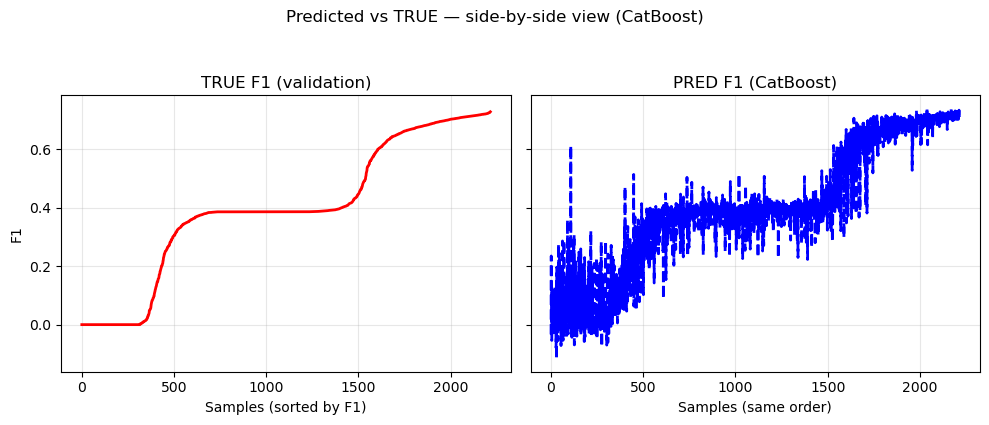

[CatBoost | VAL] RMSE=0.0650 | MAE=0.0389 | R²=0.9199


In [145]:
# Pick best by validation RMSE (from your summary)
best_name = summary.iloc[0]["name"]
best_pred_fn = next(r["predict_fn"] for r in results if r["name"] == best_name)

# Predict on VAL
yhat_val = best_pred_fn(X_va_sur)

# Sort for visual clarity
order = np.argsort(y_va_sur.values)
y_true_sorted = y_va_sur.values[order]
y_pred_sorted = yhat_val[order]

# --- Side-by-side comparison plots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# TRUE F1
axes[0].plot(y_true_sorted, "r-", lw=2)
axes[0].set_title("TRUE F1 (validation)")
axes[0].set_xlabel("Samples (sorted by F1)")
axes[0].set_ylabel("F1")
axes[0].grid(alpha=0.3)

# PREDICTED F1
axes[1].plot(y_pred_sorted, "b--", lw=2)
axes[1].set_title(f"PRED F1 ({best_name})")
axes[1].set_xlabel("Samples (same order)")
axes[1].grid(alpha=0.3)

plt.suptitle(f"Predicted vs TRUE — side-by-side view ({best_name})", y=1.05)
plt.tight_layout()
plt.show()

# Validation metrics
rmse_val = float(np.sqrt(mean_squared_error(y_va_sur, yhat_val)))
mae_val  = mean_absolute_error(y_va_sur, yhat_val)
r2_val   = r2_score(y_va_sur, yhat_val)
print(f"[{best_name} | VAL] RMSE={rmse_val:.4f} | MAE={mae_val:.4f} | R²={r2_val:.4f}")


In [146]:
# Build comparison DataFrame
compare_df = pd.DataFrame({
    "f1_true": y_true_sorted,
    "f1_predicted": y_pred_sorted
})

# Compute absolute error
compare_df["abs_error"] = (compare_df["f1_true"] - compare_df["f1_predicted"]).abs()

# Show a representative sample — bottom, middle, top of F1 range
n = len(compare_df)
sample_idx = np.unique(np.clip([0, n//4, n//2, 3*n//4, n-1], 0, n-1))
display(compare_df.iloc[sample_idx].round(4).reset_index(drop=True))

,f1_true,f1_predicted,abs_error
0,0.0000,-0.0333,0.0333
1,0.3449,0.3927,0.0478
2,0.3861,0.4072,0.0211
3,0.6330,0.6143,0.0187
4,0.7285,0.7160,0.0125


## Generating counterfactuals

In [9]:
# ===================== Weighted Ensemble: sklearn-compatible wrapper =====================

# topk = 3  # take top-k surrogates by RMSE
# top_names = summary["name"].head(topk).tolist()
# top_rmses = summary["rmse"].head(topk).to_numpy()
# top_weights = (1.0 / (top_rmses ** 2))
# top_weights = top_weights / top_weights.sum()

# # Map model name → predict function
# name_to_pred = {r["name"]: r["predict_fn"] for r in results}

# class WeightedEnsembleRegressor(BaseEstimator, RegressorMixin):
#     def __init__(self, name_to_pred, names, weights):
#         self.name_to_pred = name_to_pred
#         self.names = list(names)
#         self.weights = np.asarray(weights, dtype=float)

#     def fit(self, X, y=None):
#         return self  # no training needed

#     def predict(self, X):
#         preds = [self.name_to_pred[n](X) for n in self.names]
#         return np.tensordot(self.weights, np.vstack(preds), axes=1)

# ens_model = WeightedEnsembleRegressor(
#     name_to_pred=name_to_pred,
#     names=top_names,
#     weights=top_weights,
# )


In [222]:
# Data + Model
data_dice  = dice_ml.Data(
    dataframe=pd.concat([X_sur, y_sur], axis=1),
    continuous_features=num_cols,
    categorical_features=cat_cols,
    outcome_name="f1",
)
model_dice = dice_ml.Model(model=cb_eval, backend="sklearn", model_type="regressor")
exp        = Dice(data_dice, model_dice, method="genetic")

# Seed config (row from X_sur)
seed = X_sur.sample(1, random_state=0)

# Permitted ranges (keep it small first; add more later)
permitted_range = {
    "params_learning_rate": [1e-4, 0.5],
    "params_max_depth":     [3, 12],
    "params_n_estimators":  [200, 1000],
    "params_booster":       ["gbtree", "dart"],
}

# MUST pass desired_range for regressors; use [0,1] to be target-agnostic
cf = exp.generate_counterfactuals(
    query_instances=seed,
    total_CFs=20,
    desired_range=[0.0, 0.5],
    features_to_vary="all",
    permitted_range=permitted_range,
)
cf_df = cf.cf_examples_list[0].final_cfs_df


100%|██████████| 1/1 [00:01<00:00,  1.69s/it]


Counterfactuals found: 20


,params_alpha,params_booster,params_colsample_bytree,params_gamma,params_grow_policy,params_lambda,params_learning_rate,params_max_delta_step,params_max_depth,params_min_child_weight,...,params_labeled_ratio,params_missing_rate,params_selftrain_max_iter,params_selftrain_threshold,user_attrs_labeled_ratio,user_attrs_missing_rate,soft_risk_preference,soft_decision_speed,soft_train_rows,f1
0,1.03112,gbtree,0.724920,8.065993,depthwise,0.000714,0.001052,0,12,0.50637,...,0.9,0.0,10.0,0.9,0.9,0.1,recall_pref,balanced,17077,0.404481
0,0.00968,gbtree,0.941022,8.894319,depthwise,0.000226,0.003308,0,4,56.33359,...,0.8,0.1,10.0,0.8,0.8,0.1,recall_pref,fast,16741,0.384371
0,0.02618,gbtree,0.941022,8.894319,depthwise,0.000226,0.000100,0,4,0.10000,...,0.4,0.0,11.0,0.7,0.8,0.1,recall_pref,balanced,16981,0.411622
0,25.79470,gbtree,0.589313,5.526134,lossguide,0.050685,0.000598,10,11,0.49333,...,0.2,0.0,11.0,0.9,0.2,0.1,recall_pref,balanced,16932,0.382307
0,0.04301,gbtree,0.910698,3.257712,depthwise,0.000145,0.000308,2,9,54.34775,...,0.1,0.1,11.0,0.8,0.1,0.1,recall_pref,slow,17240,0.409287
0,0.00021,gbtree,0.721410,4.779379,depthwise,1.477921,0.004759,3,12,0.10000,...,0.7,0.1,10.0,0.9,0.3,0.0,recall_pref,balanced,14655,0.472997
0,8.57133,gbtree,0.874571,8.207723,depthwise,0.248456,0.002592,0,5,7.42205,...,0.3,0.1,8.0,0.8,0.3,0.1,recall_pref,balanced,17290,0.403360
0,0.00010,gbtree,0.851860,1.151525,depthwise,9.246486,0.000100,4,5,0.45290,...,0.3,0.5,10.0,0.9,0.1,0.1,balanced,balanced,17173,0.374930
0,0.00379,gbtree,0.721410,1.897923,depthwise,0.000329,0.029358,3,12,0.36590,...,0.3,0.3,10.0,0.8,0.3,0.3,recall_pref,balanced,17041,0.385738
0,10.02732,gbtree,0.778284,8.503031,depthwise,45.687965,0.023612,2,8,30.40519,...,0.8,0.1,8.0,0.7,0.8,0.1,recall_pref,balanced,17195,0.391569


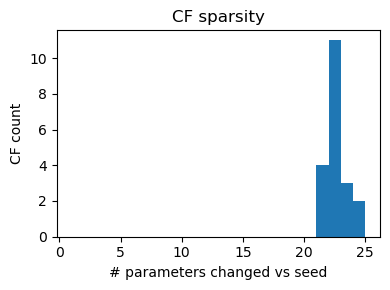

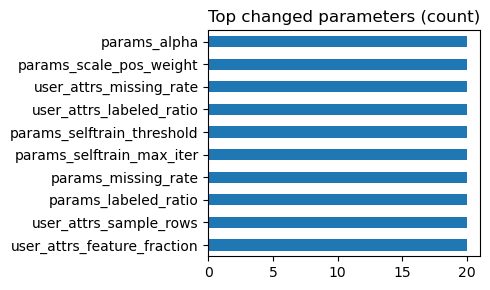

In [223]:
# ───────────────────── CF quick summary & visualization ─────────────────────

if cf_df is None or cf_df.empty:
    print("No counterfactuals found.")
else:
    # 1) Count + preview
    print(f"Counterfactuals found: {len(cf_df)}")
    display(cf_df[0:20])

    # 2) How many params changed vs seed?
    seed = query_instance.iloc[0]
    cols = cf_df.columns.intersection(query_instance.columns)  # align columns safely
    changed_mask = (cf_df[cols] != seed[cols].values).astype(int)
    changed_per_cf = changed_mask.sum(axis=1)

    plt.figure(figsize=(4,3))
    plt.hist(changed_per_cf, bins=range(1, int(changed_per_cf.max())+2))
    plt.xlabel("# parameters changed vs seed")
    plt.ylabel("CF count")
    plt.title("CF sparsity")
    plt.tight_layout()
    plt.show()

    # 3) Which parameters change most often?
    freq = changed_mask.sum(axis=0).sort_values(ascending=False).head(10)
    if len(freq) > 0:
        freq.plot.barh(figsize=(5,3))
        plt.gca().invert_yaxis()
        plt.title("Top changed parameters (count)")
        plt.tight_layout()
        plt.show()

## Evaluating counterfactuals

In [226]:
def _inject_missing(X_df, num_cols, cat_cols, rate, rng):
    if rate <= 0: 
        return X_df.copy()
    Xm = X_df.copy()
    n = len(Xm)
    for c in num_cols:
        m = rng.random(n) < rate
        if m.all(): m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    for c in cat_cols:
        m = rng.random(n) < rate
        if m.all(): m[rng.integers(0, n)] = False
        Xm.loc[m, c] = np.nan
    return Xm

def _col_slice(M, cols):
    return M[:, cols]

def _stack_rows(A, B):
    import scipy.sparse as sp
    if sp.issparse(A) or sp.issparse(B):
        A = A.tocsr() if sp.issparse(A) else sp.csr_matrix(A)
        B = B.tocsr() if sp.issparse(B) else sp.csr_matrix(B)
        return sp.vstack([A, B], format="csr")
    return np.vstack([A, B])

def _get(row, name, default, cast=float):
    v = row.get(name, default)
    try: return cast(v)
    except: return default

def evaluate_cf_row_true_exact(row):
    """Evaluate one CF row using the *same* pipeline that was used during training:
       - v3 if decision_threshold < 0.5 (full soft-knobs path)
       - v1 otherwise (hard-params only, no v3 extras)
    """
    # ---------------- Version routing (your rule) ----------------
    decision_thr = float(row.get("user_attrs_decision_threshold", 0.5))
    is_v3 = decision_thr < 0.5   # <0.5 ⇒ v3; ≥0.5 ⇒ v1

    # -------- RNGs (fixed to make verification repeatable) ------
    seed = 0
    rng_rows = np.random.default_rng(seed)

    # ---------------- Hard params (+ DART conditionals) ---------
    booster = str(row.get("params_booster", "gbtree"))

    # XGBoost uses reg_lambda/reg_alpha names
    params = dict(
        booster=booster,
        n_estimators=int(row.get("params_n_estimators", 400)),
        max_depth=int(row.get("params_max_depth", 6)),
        learning_rate=float(row.get("params_learning_rate", 0.1)),
        min_child_weight=float(row.get("params_min_child_weight", 1.0)),
        gamma=float(row.get("params_gamma", 0.0)),
        reg_lambda=float(row.get("params_lambda", 1.0)),
        reg_alpha=float(row.get("params_alpha", 0.0)),
        subsample=float(row.get("params_subsample", 0.8)),
        colsample_bytree=float(row.get("params_colsample_bytree", 0.8)),
        grow_policy=str(row.get("params_grow_policy", "depthwise")),
        max_delta_step=int(row.get("params_max_delta_step", 0)),
        objective="binary:logistic",
        eval_metric="error",
        tree_method="hist",
        device="cuda",
        missing=np.nan,
        random_state=0,
        verbosity=0,
    )

    if booster == "dart":
        # sanitize tokens to valid values
        st = str(row.get("params_sample_type", "uniform"))
        nt = str(row.get("params_normalize_type", "tree"))
        params.update(
            rate_drop=float(row.get("params_rate_drop", 0.0)),
            skip_drop=float(row.get("params_skip_drop", 0.0)),
            sample_type=st if st in {"uniform", "weighted"} else "uniform",
            normalize_type=nt if nt in {"tree", "forest"} else "tree",
        )

    # ---------------- Preprocess (same both versions) ------------
    # OHE for cats (impute mode) + passthrough numerics (XGB handles NaN)
    preproc = ColumnTransformer([
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat),
        ("num", "passthrough", num),
    ])

    # ---------------- v1 path (no v3 extras) ---------------------
    if not is_v3:
        # v1: no row subsample; no missing injection; no resampling; no feature_fraction; no self-training
        Xtr_enc = preproc.fit_transform(X_tr)
        Xva_enc = preproc.transform(X_va)
        Xte_enc = preproc.transform(X_te)

        import scipy.sparse as sp
        if sp.issparse(Xtr_enc): Xtr_enc = Xtr_enc.tocsr()
        if sp.issparse(Xva_enc): Xva_enc = Xva_enc.tocsr()
        if sp.issparse(Xte_enc): Xte_enc = Xte_enc.tocsr()

        clf = xgb.XGBClassifier(**params).fit(Xtr_enc, y_tr)

        # Threshold picked on VAL; applied to TEST
        proba_va = clf.predict_proba(Xva_enc)[:, 1]
        prec, rec, thr = precision_recall_curve(y_va, proba_va)
        f1s = 2 * prec * rec / (prec + rec + 1e-12)
        j = f1s.argmax()
        thr_best = 0.5 if j >= len(thr) else float(thr[j])

        yhat_va = (proba_va >= thr_best).astype(int)
        proba_te = clf.predict_proba(Xte_enc)[:, 1]
        yhat_te  = (proba_te >= thr_best).astype(int)

        return {
            "f1_val":  f1_score(y_va, yhat_va, zero_division=0),
            "f1_test": f1_score(y_te, yhat_te, zero_division=0),
            "acc_val": accuracy_score(y_va, yhat_va),
            "acc_test": accuracy_score(y_te, yhat_te),
            "prec_val": precision_score(y_va, yhat_va, zero_division=0),
            "prec_test": precision_score(y_te, yhat_te, zero_division=0),
            "rec_val":  recall_score(y_va, yhat_va, zero_division=0),
            "rec_test": recall_score(y_te, yhat_te, zero_division=0),
            "roc_auc_val": roc_auc_score(y_va, proba_va),
            "roc_auc_test": roc_auc_score(y_te, proba_te),
            "pr_auc_val": average_precision_score(y_va, proba_va),
            "pr_auc_test": average_precision_score(y_te, proba_te),
            "best_threshold": thr_best,
        }

    # ---------------- v3 path (with soft knobs) ------------------
    # 1) stratified row subsample
    y_tr_np = np.asarray(y_tr, dtype=int)
    pos = np.where(y_tr_np == 1)[0]
    neg = np.where(y_tr_np == 0)[0]
    sample_rows = float(row.get("user_attrs_sample_rows", row.get("params_sample_rows", 1.0)))
    sample_rows = float(np.clip(sample_rows, 0.5, 1.0))
    n_pos = max(1, int(len(pos) * sample_rows))
    n_neg = max(1, int(len(neg) * sample_rows))
    keep = np.concatenate([
        rng_rows.choice(pos, n_pos, replace=False),
        rng_rows.choice(neg, n_neg, replace=False)
    ])
    rng_rows.shuffle(keep)

    # 2) inject missing into TRAIN only (snap to grid)
    u = float(row.get("params_missing_rate", 0.0))
    grid = np.array([0.00, 0.02, 0.05, 0.08, 0.10])
    missing_rate = float(grid[np.argmin(np.abs(grid - u))])
    rng_mask = np.random.default_rng((seed, int(round(missing_rate * 100))))

    X_tr_masked = _inject_missing(X_tr.iloc[keep], num, cat, missing_rate, rng_mask)
    X_va_masked = X_va
    X_te_masked = X_te

    Xtr_enc = preproc.fit_transform(X_tr_masked)
    Xva_enc = preproc.transform(X_va_masked)
    Xte_enc = preproc.transform(X_te_masked)

    import scipy.sparse as sp
    if sp.issparse(Xtr_enc): Xtr_enc = Xtr_enc.tocsr()
    if sp.issparse(Xva_enc): Xva_enc = Xva_enc.tocsr()
    if sp.issparse(Xte_enc): Xte_enc = Xte_enc.tocsr()

    ytr_sub = y_tr_np[keep].astype(int)

    # 3) resampling vs scale_pos_weight
    resampling = str(row.get("user_attrs_resampling_strategy",
                             row.get("params_resampling", "none"))).lower()
    if resampling != "none":
        params["scale_pos_weight"] = 1.0
        posk, negk = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        if len(posk) and len(negk):
            if resampling == "undersample":
                n = min(len(posk), len(negk))
                idx = np.concatenate([
                    rng_rows.choice(posk, n, replace=False),
                    rng_rows.choice(negk, n, replace=False)
                ])
                Xtr_enc, ytr_sub = Xtr_enc[idx], ytr_sub[idx]
            elif resampling == "oversample":
                n = max(len(posk), len(negk))
                addp = rng_rows.choice(posk, n - len(posk), replace=True) if len(posk) < n else np.array([], int)
                addn = rng_rows.choice(negk, n - len(negk), replace=True) if len(negk) < n else np.array([], int)
                add = np.concatenate([addp, addn])
                if add.size:
                    Xtr_enc = _stack_rows(Xtr_enc, Xtr_enc[add])
                    ytr_sub = np.concatenate([ytr_sub, ytr_sub[add]]).astype(int)
    else:
        params["scale_pos_weight"] = float(row.get("params_scale_pos_weight", 1.0))

    # 4) feature fraction
    ff = float(row.get("user_attrs_feature_fraction", row.get("params_feature_fraction", 1.0)))
    ff = float(np.clip(ff, 0.5, 1.0))
    nF = Xtr_enc.shape[1]
    kF = max(1, int(nF * ff))
    feat_idx = np.sort(rng_rows.choice(np.arange(nF), size=kF, replace=False))

    def _col_slice(M, cols): return M[:, cols]
    Xtr_sub = _col_slice(Xtr_enc, feat_idx)
    Xva_sub = _col_slice(Xva_enc, feat_idx)
    Xte_sub = _col_slice(Xte_enc, feat_idx)

    # 5) semi-supervised (SelfTraining)
    labeled_ratio = float(row.get("params_labeled_ratio", row.get("user_attrs_labeled_ratio", 1.0)))
    if labeled_ratio < 1.0 and len(np.unique(ytr_sub)) == 2:
        pidx, nidx = np.where(ytr_sub == 1)[0], np.where(ytr_sub == 0)[0]
        kp = max(1, int(round(len(pidx) * labeled_ratio))); kp = min(kp, len(pidx))
        kn = max(1, int(round(len(nidx) * labeled_ratio))); kn = min(kn, len(nidx))
        keep_lab = np.concatenate([
            rng_rows.choice(pidx, kp, replace=False),
            rng_rows.choice(nidx, kn, replace=False)
        ])
        ysemi = np.full_like(ytr_sub, -1)
        ysemi[keep_lab] = ytr_sub[keep_lab]
        clf = SelfTrainingClassifier(
            estimator=xgb.XGBClassifier(**params),
            threshold=float(row.get("params_selftrain_threshold", 0.7)),
            max_iter=int(row.get("params_selftrain_max_iter", 8)),
            verbose=False
        ).fit(Xtr_sub, ysemi)
    else:
        clf = xgb.XGBClassifier(**params).fit(Xtr_sub, ytr_sub)

    # 6) VAL threshold → report VAL/TEST
    y_va_int = np.asarray(y_va, int); y_te_int = np.asarray(y_te, int)
    proba_va = clf.predict_proba(Xva_sub)[:, 1]
    prec, rec, thr = precision_recall_curve(y_va_int, proba_va)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    j = f1s.argmax()
    thr_best = 0.5 if j >= len(thr) else float(thr[j])

    yhat_va = (proba_va >= thr_best).astype(int)
    proba_te = clf.predict_proba(Xte_sub)[:, 1]
    yhat_te  = (proba_te >= thr_best).astype(int)

    return {
        "f1_val":  f1_score(y_va_int, yhat_va, zero_division=0),
        "f1_test": f1_score(y_te_int, yhat_te, zero_division=0),
        "acc_val": accuracy_score(y_va_int, yhat_va),
        "acc_test": accuracy_score(y_te_int, yhat_te),
        "prec_val": precision_score(y_va_int, yhat_va, zero_division=0),
        "prec_test": precision_score(y_te_int, yhat_te, zero_division=0),
        "rec_val":  recall_score(y_va_int, yhat_va, zero_division=0),
        "rec_test": recall_score(y_te_int, yhat_te, zero_division=0),
        "roc_auc_val": roc_auc_score(y_va_int, proba_va),
        "roc_auc_test": roc_auc_score(y_te_int, proba_te),
        "pr_auc_val": average_precision_score(y_va_int, proba_va),
        "pr_auc_test": average_precision_score(y_te_int, proba_te),
        "best_threshold": thr_best,
    }



In [227]:
rows = []
for i, r in cf_df.iterrows():
    m = evaluate_cf_row_true_exact(r)
    m["cf_index"] = i
    m["f1_predicted"] = float(r.get("f1", np.nan))  # surrogate’s prediction
    rows.append(m)
results_df = pd.DataFrame(rows).sort_values("f1_test", ascending=False)
display(results_df.head(15))


,f1_val,f1_test,acc_val,acc_test,prec_val,prec_test,rec_val,rec_test,roc_auc_val,roc_auc_test,pr_auc_val,pr_auc_test,best_threshold,cf_index,f1_predicted
8,0.725361,0.722131,0.863636,0.861194,0.699960,0.693155,0.752674,0.753636,0.924966,0.926604,0.821010,0.826019,0.373245,0,0.385738
15,0.720100,0.719717,0.862715,0.861910,0.702934,0.699798,0.738126,0.740804,0.924134,0.926338,0.818865,0.827077,0.381811,0,0.239342
16,0.706137,0.707312,0.861282,0.859453,0.715919,0.705057,0.696620,0.709581,0.916922,0.919335,0.802506,0.810909,0.420149,0,0.382065
0,0.703185,0.700358,0.856880,0.854335,0.697851,0.689755,0.708601,0.711292,0.911725,0.913060,0.796354,0.805170,0.278201,0,0.404481
17,0.697448,0.699177,0.847052,0.846555,0.662053,0.658601,0.736842,0.745081,0.910608,0.912809,0.790615,0.799565,0.271887,0,0.008763
9,0.695980,0.695778,0.851351,0.848807,0.681427,0.671037,0.711168,0.722412,0.911774,0.913249,0.788091,0.796925,0.381878,0,0.391569
14,0.695230,0.695078,0.845618,0.843996,0.658751,0.653008,0.735986,0.742943,0.909717,0.911590,0.789048,0.796856,0.288822,0,0.197747
18,0.686051,0.684242,0.841933,0.838162,0.653623,0.641813,0.721866,0.732678,0.902052,0.904328,0.760545,0.769878,0.242644,0,0.457841
3,0.681809,0.684071,0.830774,0.829051,0.619664,0.613297,0.757809,0.773311,0.901684,0.903501,0.771387,0.778851,0.251579,0,0.382307
6,0.685312,0.678746,0.826065,0.818508,0.604180,0.588809,0.791613,0.801112,0.903817,0.906252,0.777807,0.789600,0.296426,0,0.403360
